Saving gettyimages-2053370092-612x612.jpg to gettyimages-2053370092-612x612.jpg
Filename: gettyimages-2053370092-612x612.jpg
Image shape: (408, 612, 3)


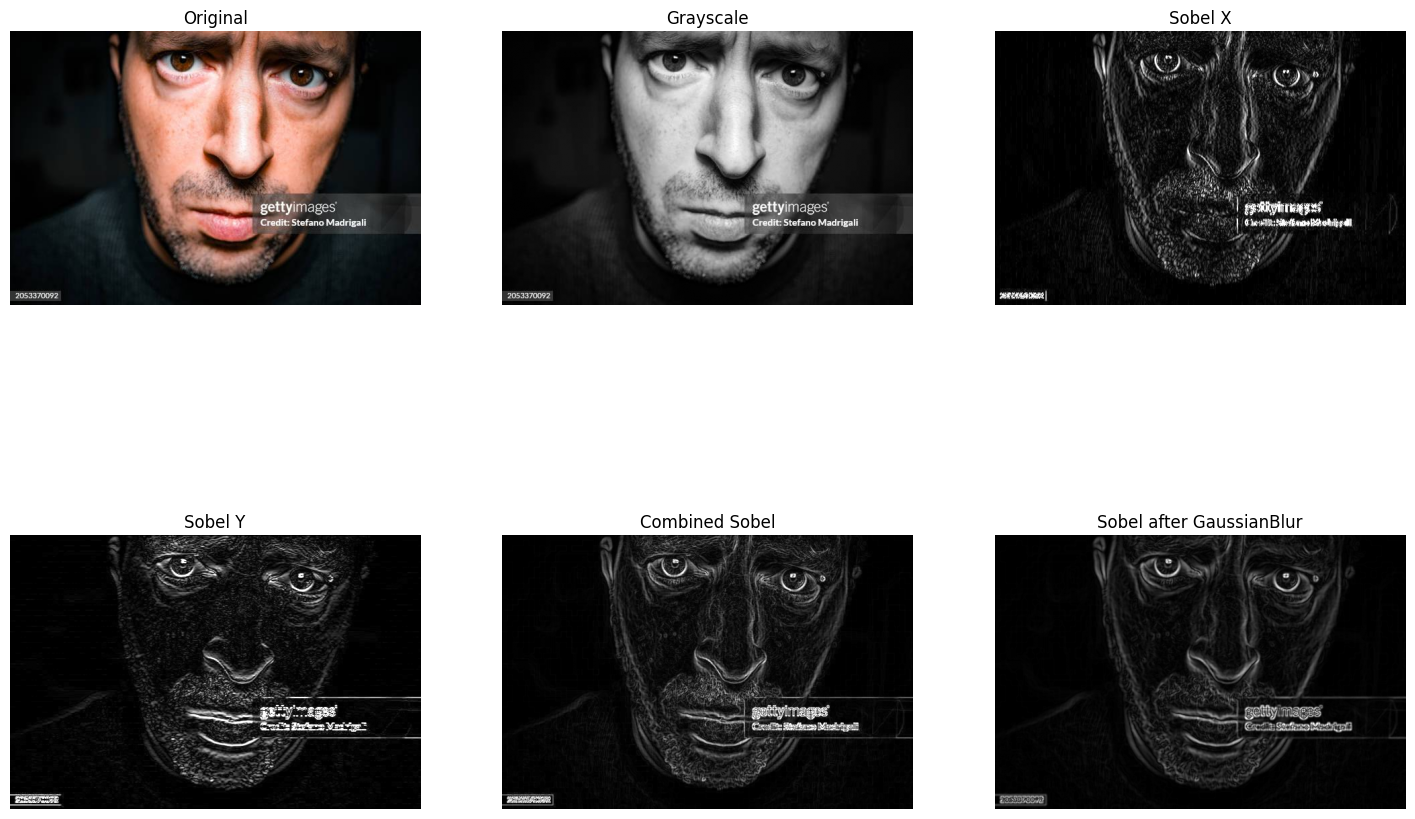

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Filename:", filename)

image = cv2.imread(filename)

if image is None:
    print("Ошибка чтения изображения")

else:
    print("Image shape:", image.shape)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    sobel_x = cv2.Sobel(
        gray,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    sobel_y = cv2.Sobel(
        gray,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    sobel_x_abs = cv2.convertScaleAbs(sobel_x)

    sobel_y_abs = cv2.convertScaleAbs(sobel_y)

    sobel_combined = cv2.addWeighted(
        sobel_x_abs,
        0.5,
        sobel_y_abs,
        0.5,
        0
    )

    blurred = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    sobel_x_blur = cv2.Sobel(
        blurred,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    sobel_y_blur = cv2.Sobel(
        blurred,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    sobel_x_blur_abs = cv2.convertScaleAbs(
        sobel_x_blur
    )

    sobel_y_blur_abs = cv2.convertScaleAbs(
        sobel_y_blur
    )

    sobel_blur_combined = cv2.addWeighted(
        sobel_x_blur_abs,
        0.5,
        sobel_y_blur_abs,
        0.5,
        0
    )

    plt.figure(figsize=(18, 12))




    plt.subplot(2, 3, 1)

    plt.imshow(image_rgb)

    plt.title("Original")

    plt.axis("off")




    plt.subplot(2, 3, 2)

    plt.imshow(gray, cmap="gray")

    plt.title("Grayscale")

    plt.axis("off")




    plt.subplot(2, 3, 3)

    plt.imshow(sobel_x_abs, cmap="gray")

    plt.title("Sobel X")

    plt.axis("off")




    plt.subplot(2, 3, 4)

    plt.imshow(sobel_y_abs, cmap="gray")

    plt.title("Sobel Y")

    plt.axis("off")




    plt.subplot(2, 3, 5)

    plt.imshow(sobel_combined, cmap="gray")

    plt.title("Combined Sobel")

    plt.axis("off")




    plt.subplot(2, 3, 6)

    plt.imshow(
        sobel_blur_combined,
        cmap="gray"
    )

    plt.title("Sobel after GaussianBlur")

    plt.axis("off")


    plt.show()

In [ ]:
# 1) Какие границы лучше всего нашёл Sobel?
# 2) Что лучше видно на Sobel X?
# 3) Что лучше видно на Sobel Y?
# 4) Где Sobel сработал плохо?
# 5) Что изменилось после GaussianBlur?
# 6) Стало ли меньше шума?

# для лица:
# 1) sobel хорошо выделил контуры лица, глаз, носа
# 2) sobel x выделил вертикальные линии
# 3) sobel y - горизонтальные
# 4) плохо выделились участки без резких переходов яркости
# 5 - 6) gausian blur убирает шум с картинки

# для города:
# 1) sobel выделил окна, двери, границы зданий
# 2) sobel x выделил горизонтальные линии
# 3) sobel y - вертикальные
# 4) плохо выделились участки где есть большая тень или наоборот много света
# 5 - 6) gausian blur убирает шум с картинки

# для обьекта на столе:
# 1) выделились форма и границы обьектов на столе
# 2) sobel x обнаружил края предметов
# 3) sobel y верхние и нижние границы
# 4) все блестящие места обьекта плохо обнаружились
# 5 - 6) также убрал шум и ненужные линии

# 7) Какое из трёх изображений лучше всего подходит для Sobel и почему?
# фото с городом лучше всето из-за наличия многих прямых линий - окна, здания, улица
# 8) Почему поиск границ важен для Computer Vision?
# границы определяют обьект, в этом смысл CV - найти обьект для дальнейших манипуляций с ним
